In [1]:
import numpy as np
import pandas as pd

C:\Users\desai\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [6]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [8]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [9]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [11]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [12]:
y

array([1, 0, 1, ..., 1, 1, 0], dtype=int64)

In [13]:
X_train.shape

(8000, 11)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [15]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [16]:
model = Sequential()


# 1 hidden layer with 3 nodes getting input from 11 features with Sigmoid Activiation fn
model.add(Dense(3, activation='sigmoid', input_dim=11))
# output layer with 1 node (single class classification)
model.add(Dense(1, activation='sigmoid'))

C:\Users\desai\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 3)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss='binary_crossentropy', optimizer='Adam')

In [20]:
model.fit(X_train_trf, y_train, epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4999
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4856
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4642
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4534
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4396
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4511
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4303
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4308
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4274
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4341


In [22]:
# weights of layer 1 = 33 weights + 3 biases
model.layers[0].get_weights()

[array([[ 0.17710827,  0.13325772, -0.3686365 ],
        [-1.3741894 , -1.0568057 , -0.94727683],
        [-0.0491857 ,  0.25398356,  0.01562816],
        [ 0.0042443 , -0.06313176, -0.9316967 ],
        [ 0.24049298,  0.16576895,  0.30268842],
        [ 0.16284244, -0.21124601,  0.41568384],
        [ 0.67780256,  0.4666792 ,  0.7163212 ],
        [-0.05341426, -0.11044379,  0.30193523],
        [-0.66113293, -0.6700812 , -0.0164701 ],
        [ 0.12356533, -0.18814789, -0.4195783 ],
        [ 0.02567192,  0.77254915,  0.75955087]], dtype=float32),
 array([ 0.23145653,  0.04347254, -0.00992432], dtype=float32)]

In [23]:
model.layers[1].get_weights()

[array([[-1.5349685 ],
        [-1.4090354 ],
        [-0.41527098]], dtype=float32),
 array([0.1504045], dtype=float32)]

In [25]:
y_log = model.predict(X_test_trf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [27]:
y_pred = np.where(y_log>0.5, 1, 0)

In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.804

Improve Performance:
1. Increase no of epochs
2. Activation function: Relu
3. Add nodes in the hidden layer
4. Increase no of hidden layers

In [29]:
model_2 = Sequential()
model_2.add(Dense(11, activation='relu', input_dim=11))
model_2.add(Dense(11, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))

C:\Users\desai\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# 133+133+12
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model_2.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [38]:
history = model_2.fit(X_train_trf, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8259 - loss: 0.3923 - val_accuracy: 0.8300 - val_loss: 0.3980
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8264 - loss: 0.3889 - val_accuracy: 0.8306 - val_loss: 0.3954
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8333 - loss: 0.3843 - val_accuracy: 0.8344 - val_loss: 0.3914
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8344 - loss: 0.3772 - val_accuracy: 0.8331 - val_loss: 0.3888
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8341 - loss: 0.3710 - val_accuracy: 0.8356 - val_loss: 0.3876
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8412 - loss: 0.3641 - val_accuracy: 0.8338 - val_loss: 0.3841
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8351 - loss: 0.3761 - val_accuracy: 0.8350 - val_loss: 0.3818
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8359 - loss: 0.3670 - val_accuracy: 0.

In [34]:
model_2.layers[2].get_weights()

[array([[ 0.4926934 ],
        [-0.67605406],
        [-0.60035765],
        [-0.53713036],
        [ 0.666625  ],
        [-0.5373804 ],
        [-0.8031713 ],
        [-0.8780172 ],
        [-0.75506145],
        [-0.15380003],
        [ 0.5433743 ]], dtype=float32),
 array([-0.06784346], dtype=float32)]

In [35]:
y_log = model_2.predict(X_test_trf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [36]:
y_pred = np.where(y_log>0.5, 1, 0)

In [37]:
accuracy_score(y_test,y_pred)

0.8235

In [39]:
history.history

{'accuracy': [0.8309375047683716,
  0.8304687738418579,
  0.8307812213897705,
  0.8310937285423279,
  0.8339062333106995,
  0.8345312476158142,
  0.8357812762260437,
  0.8354687690734863,
  0.83984375,
  0.8434374928474426],
 'loss': [0.38714951276779175,
  0.3834476172924042,
  0.3811856508255005,
  0.37956535816192627,
  0.3759516179561615,
  0.37396442890167236,
  0.37171027064323425,
  0.36915671825408936,
  0.36715999245643616,
  0.36560478806495667],
 'val_accuracy': [0.8299999833106995,
  0.8306249976158142,
  0.8343750238418579,
  0.8331249952316284,
  0.8356249928474426,
  0.8337500095367432,
  0.8349999785423279,
  0.8349999785423279,
  0.8374999761581421,
  0.8374999761581421],
 'val_loss': [0.39804673194885254,
  0.3953501582145691,
  0.39142170548439026,
  0.3888031840324402,
  0.38760003447532654,
  0.38407599925994873,
  0.38180187344551086,
  0.38026192784309387,
  0.3789267838001251,
  0.37985169887542725]}

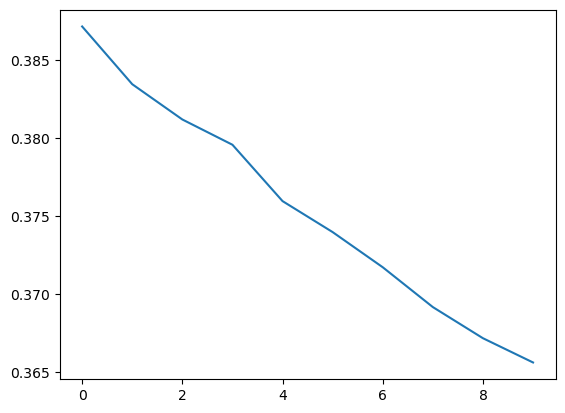

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])

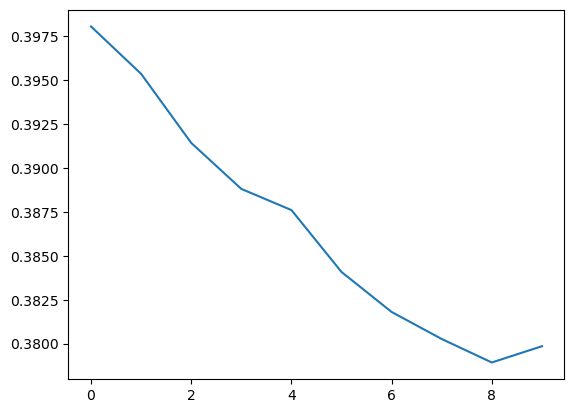

In [41]:
plt.plot(history.history['val_loss'])

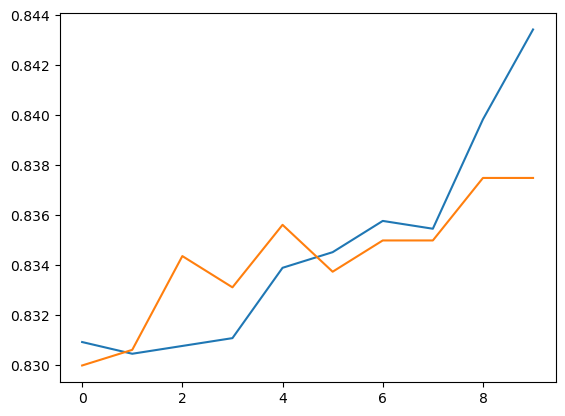

In [42]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])